# 11.2.2 连通性、模态与容积

## 学习目标与先修知识

用拉普拉斯零模态（mode）解释平衡（equilibrium）并核验数值步长。

先修：11.2.1 对称拉普拉斯；3.3 多室总量和浓度（concentration）；2.4 数值步长。

In [ ]:
from systems_science.local_service import notebook_service_ready
notebook_service_ready()

## 具体问题

切断连接桥后，两个细胞群还能达到同一个平均值吗？若室容积不同，长期平衡的浓度和总量又是否相等？这些问题分别属于连接结构和状态（state）单位。

In [1]:
import math
import random
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager
from systems_science import plot_style, show_table
plot_style()
font_names = {font.name for font in font_manager.fontManager.ttflist}
for name in ("Microsoft YaHei", "SimHei", "Noto Sans CJK SC"):
    if name in font_names:
        plt.rcParams["font.sans-serif"] = [name, "DejaVu Sans"]
        break
BLUE, PINK, GREEN = "#008bfb", "#ff0051", "#00a56a"

## 初步实验

先比较 0—1、2—3 两个断开的分量：把两个初始总量分别手算，再预测末态。

In [2]:
print('分量{0,1}初始4 U，{2,3}初始2 U；等容积时预期分别趋向2 U和1 U。')

分量{0,1}初始4 U，{2,3}初始2 U；等容积时预期分别趋向2 U和1 U。


## 模型假设

谱分解只用于无向对称交换且等容积；非零模态按 $e^{-\lambda t}$ 衰减。容积不等时用浓度 $c_i=m_i/V_i$ 与物理边系数 $g_{ij}$（单位 V/T）计算总量流率（flow rate），方程为 $\dot m=-L_gc$；体积为正、边系数非负。判断连通性时只保留交换系数大于零的边；系数为零相当于关闭通道，不把画出的零权边算作连接。显式 Euler 的非负条件是当前数值格式的充分条件，不是连续模型（model）的限制。

## 数学解释与推导

等容积归一化模型的 $L_k=Q\Lambda Q^\mathsf T$ 对称时，$x(t)=Q\exp(-\Lambda t)Q^\mathsf Tx(0)$。每个连通分量（connected component）对应一个零特征值（zero eigenvalue）的常值模态；其初始总量独立保存。连通图的最小正特征值（eigenvalue） $\lambda_2$ 控制最慢非平衡（nonequilibrium）模态的衰减尺度，但具体轨迹（trajectory）还取决于初态投影（projection）。容积不同时，$\dot m=-L_g(m/V)$；等容积 $V_i=V_0$ 时，归一化系数 $k_{ij}=g_{ij}/V_0$，所以 $L_k=L_g/V_0$。仍有 $\sum_i m_i$ 守恒；连通分量内末态浓度相等，因此对每个连通分量分别有 $m_i^*=V_i\sum_{j\in C(i)}m_j(0)/\sum_{j\in C(i)}V_j$，其中 $C(i)$ 是节点 $i$ 所在连通分量，不是各室总量相等。显式一步 $m_i^{+}=m_i[1-h\sum_jg_{ij}/V_i]+h\sum_j g_{ij}m_j/V_j$。仅对加权度 $d_i=\sum_jg_{ij}>0$ 的节点，要求 $h\le\min_{i:d_i>0}V_i/d_i$，即可保证从非负初值（initial condition）继续非负。孤立节点 $d_i=0$ 时总量不变，不限制步长；若全图无边，也无交换步长上界。

## 核心实现

下面将本节推导写成可运行函数。

In [3]:
def laplacian(n, weighted_edges):
    """Symmetric exchange operator; an edge is [i,j,rate]."""
    import numpy as np
    matrix = np.zeros((n, n), dtype=float)
    for i, j, rate in weighted_edges:
        matrix[i, i] += rate
        matrix[j, j] += rate
        matrix[i, j] -= rate
        matrix[j, i] -= rate
    return matrix.tolist()


def diffuse_amounts(n, weighted_edges, initial, volumes, dt, steps):
    """Forward Euler for dm/dt=-L(m/V); returns initial and subsequent amounts."""
    import numpy as np
    operator = np.asarray(laplacian(n, weighted_edges), dtype=float)
    volume = np.asarray(volumes, dtype=float)
    amount = np.asarray(initial, dtype=float)
    history = [amount.tolist()]
    for _ in range(steps):
        amount = amount - dt * (operator @ (amount / volume))
        history.append(amount.tolist())
    return history


def exact_equal_volume(n, weighted_edges, initial, time):
    """Spectral solution for equal unit volumes and symmetric exchange."""
    import numpy as np
    operator = np.asarray(laplacian(n, weighted_edges), dtype=float)
    values, vectors = np.linalg.eigh(operator)
    return (vectors @ (np.exp(-values * time) * (vectors.T @ initial))).tolist(), values.tolist()

## 对照实验

左图将断连网络的精确谱解与细步长 Euler 对照；右图比较不同容积的总量与共同浓度。

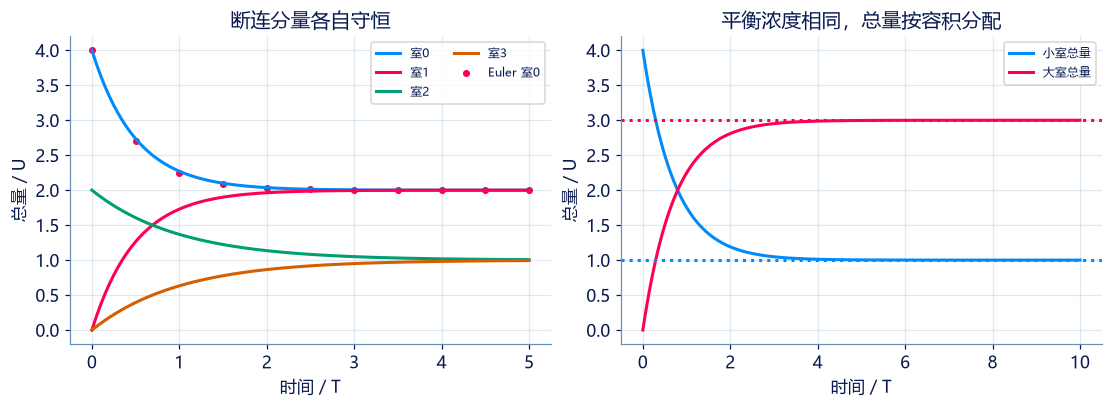

In [4]:
edges = [[0,1,1.],[2,3,.5]]; start=[4.,0.,2.,0.]
times=np.linspace(0,5,101)
exact=np.array([exact_equal_volume(4,edges,start,float(t))[0] for t in times])
euler=np.array(diffuse_amounts(4,edges,start,[1.]*4,.05,100))
unequal=np.array(diffuse_amounts(2,[[0,1,1.]],[4.,0.],[1.,3.],.05,200))
fig,axes=plt.subplots(1,2,figsize=(10,3.6))
for i in range(4): axes[0].plot(times,exact[:,i],label=f'室{i}')
axes[0].scatter(times[::10],euler[::10,0],s=13,color=PINK,label='Euler 室0')
axes[0].set(xlabel='时间 / T',ylabel='总量 / U',title='断连分量各自守恒');axes[0].legend(ncol=2,fontsize=8)
axes[1].plot(np.arange(len(unequal))*.05,unequal[:,0],label='小室总量')
axes[1].plot(np.arange(len(unequal))*.05,unequal[:,1],label='大室总量')
axes[1].axhline(1,color=BLUE,ls=':');axes[1].axhline(3,color=PINK,ls=':')
axes[1].set(xlabel='时间 / T',ylabel='总量 / U',title='平衡浓度相同，总量按容积分配');axes[1].legend(fontsize=8);plt.show()

## 结果解释

断连图保留两个平衡值；不同容积时大室在共同浓度下储存更多总量。图中 Euler 标记与精确曲线相近只说明所用步长下误差小，仍需网格细化与非负性（nonnegativity）检查。

### 独立核对

核对两分量精确总量、四个特征值中的两个零值、容积加权末态；再展示大步长守恒却产生负值的反例。

In [5]:
last, eig = exact_equal_volume(4,edges,start,20.)
assert sum(abs(v)<1e-10 for v in eig)==2
np.testing.assert_allclose(np.sum(exact[:,:2],axis=1),4.,atol=1e-10)
np.testing.assert_allclose(np.sum(exact[:,2:],axis=1),2.,atol=1e-10)
np.testing.assert_allclose(unequal[-1],[1.,3.],atol=1e-4)
bad=diffuse_amounts(2,[[0,1,1.]],[2.,0.],[1.,1.],1.5,1)[-1]
assert min(bad)<0 and abs(sum(bad)-2)<1e-12
print('谱零模态、分量守恒、容积平衡及过大步长反例均成立。')

谱零模态、分量守恒、容积平衡及过大步长反例均成立。


[在本章探索中改变条件](http://127.0.0.1:8000/chapters/11-02-%E7%BD%91%E7%BB%9C%E4%B8%8A%E7%9A%84%E6%89%A9%E6%95%A3%E4%B8%8E%E5%AE%88%E6%81%92/explore/)：先预测结果，再比较图形与数值。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · Python 计算题：按容积交换物质总量

amount[i] 是第 i 室的所追踪物质总量（tracked amount），volume[i]>0；浓度（concentration） c_i=amount_i/volume_i。物理边系数 g_ij=rate，单位 V/T；边总量流率（flow rate） g_ij·(c_i−c_j)，用题给固定步长显式 Euler 更新指定步数，返回包含初态的每步总量列表。

**函数与代码模板**

```python
def solve(
    n: int,
    weighted_edges: list[list[float]],
    initial: list[float],
    volumes: list[float],
    dt: float,
    steps: int,
) -> list[list[float]]:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `n` | `int` | 室数。 | 个 |
| `weighted_edges` | `list[list[float]]` | 无向对称物理交换边 [i,j,g_ij]。 | 容积/T |
| `initial` | `list[float]` | 初始各室所追踪物质总量。 | U |
| `volumes` | `list[float]` | 各室容积。 | V |
| `dt` | `float` | 固定数值步长。 | T |
| `steps` | `int` | 更新次数。 | 步 |

**返回值**

直接返回 history（list[list[float]]）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `history` | `list[list[float]]` | 长度 steps+1 的各室总量轨迹（trajectory）。 | U |

**计算规则**

每步同时用旧总量计算浓度，m_next=m−dt·L_g(m/V)。令 d_i=∑_j rate_ij；对 d_i>0 的节点，输入（input）保证 dt≤min_{i:d_i>0}(V_i/d_i)，故轨迹非负。孤立节点 d_i=0 不限制步长；全图无边时没有交换步长上界。

**约束与边界**

- 只计算题定有限图和数值模型（model）；返回普通 Python 列表、数值或元组。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| n | 室数。 | 2 | 个 |
| weighted_edges | 无向对称物理交换边 [i,j,g_ij]。 | [[0, 1, 1.0]] | 容积/T |
| initial | 初始各室所追踪物质总量。 | [2.0, 0.0] | U |
| volumes | 各室容积。 | [1.0, 1.0] | V |
| dt | 固定数值步长。 | 0.25 | T |
| steps | 更新次数。 | 2 | 步 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
n = 2
weighted_edges = [[0, 1, 1.0]]
initial = [2.0, 0.0]
volumes = [1.0, 1.0]
dt = 0.25
steps = 2

result = solve(n, weighted_edges, initial, volumes, dt, steps)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| history | 长度 steps+1 的各室总量轨迹（trajectory）。 | [[2.0, 0.0], [1.5, 0.5], [1.25, 0.75]] | U |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = [[2.0, 0.0], [1.5, 0.5], [1.25, 0.75]]
```

**样例解释**

首例第一步为[1.5,0.5]，两室总量之和始终为2；不同容积时长期相等的是浓度而不是总量。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：按容积交换物质总量](http://127.0.0.1:8000/chapters/11-02-%E7%BD%91%E7%BB%9C%E4%B8%8A%E7%9A%84%E6%89%A9%E6%95%A3%E4%B8%8E%E5%AE%88%E6%81%92/practice/?question=p11-amounts-with-volumes)

### 第 2 题 · 单项选择题：不同容积时的平衡

两个相连容积分别为1 V、3 V，总量共8 U且没有输入（input）输出（output）。最终浓度（concentration）和两室总量应为多少？

- **A.** 浓度各2 U/V；总量分别2 U、6 U。
- **B.** 总量各4 U；浓度各4和4/3 U/V。
- **C.** 浓度各4 U/V；总量共16 U。
- **D.** 无法由质量守恒与浓度相等确定。

[作答：不同容积时的平衡](http://127.0.0.1:8000/chapters/11-02-%E7%BD%91%E7%BB%9C%E4%B8%8A%E7%9A%84%E6%89%A9%E6%95%A3%E4%B8%8E%E5%AE%88%E6%81%92/practice/?question=p11-volume-equilibrium)

### 第 3 题 · 单项选择题：守恒不等于物理合理

无向交换显式 Euler 步长很大，数值结果出现某室负总量，但各室总和仍守恒。应如何解释？

- **A.** 守恒通过就证明数值结果可用。
- **B.** 这是离散步长造成的非负性（nonnegativity）失败；应细化步长或选合适方法。
- **C.** 真实物质出现负量。
- **D.** 一定是图不连通。

[作答：守恒不等于物理合理](http://127.0.0.1:8000/chapters/11-02-%E7%BD%91%E7%BB%9C%E4%B8%8A%E7%9A%84%E6%89%A9%E6%95%A3%E4%B8%8E%E5%AE%88%E6%81%92/practice/?question=p11-euler-too-large)

### 第 4 题 · 单项选择题：谱间隔能说明什么

相同等容积无向连通网络，L 的最小非零特征值（nonzero eigenvalue）较大。以下哪项在本模型（model）内有根据？

- **A.** 最慢非平衡（nonequilibrium）模态（mode）的指数衰减更快。
- **B.** 任何有向感染过程也必更快。
- **C.** 有限步长 Euler 总是更稳定。
- **D.** 所有节点有完全相同的瞬时轨迹（trajectory）。

[作答：谱间隔能说明什么](http://127.0.0.1:8000/chapters/11-02-%E7%BD%91%E7%BB%9C%E4%B8%8A%E7%9A%84%E6%89%A9%E6%95%A3%E4%B8%8E%E5%AE%88%E6%81%92/practice/?question=p11-spectral-gap)

**进一步阅读**

[NetworkX 图矩阵文档](https://networkx.org/documentation/stable/reference/linalg.html)给出拉普拉斯定义；精确谱解与显式格式的区别由本节推导。